<a href="https://www.kaggle.com/code/lalit7881/formula-1-race-results-2019-24-94?scriptVersionId=325094890" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn  as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ibrahimqasimi/formula-1-race-results-2019-2024/16_F1_Race_Results_2019_2024.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ibrahimqasimi/formula-1-race-results-2019-2024/16_F1_Race_Results_2019_2024.csv")

In [3]:
df.head()

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,season,Set Fastest Lap,Fastest Lap Time,Total Time/Gap/Retirement
0,Bahrain,1,16,Charles Leclerc,Ferrari,1.0,57,1:37:33.584,26.0,Yes,1:34.570,2022,NaN,NaN,NaN
1,Bahrain,2,55,Carlos Sainz,Ferrari,3.0,57,+5.598,18.0,No,1:35.740,2022,NaN,NaN,NaN
2,Bahrain,3,44,Lewis Hamilton,Mercedes,5.0,57,+9.675,15.0,No,1:36.228,2022,NaN,NaN,NaN
3,Bahrain,4,63,George Russell,Mercedes,9.0,57,+11.211,12.0,No,1:36.302,2022,NaN,NaN,NaN
4,Bahrain,5,20,Kevin Magnussen,Haas Ferrari,7.0,57,+14.754,10.0,No,1:36.623,2022,NaN,NaN,NaN


In [4]:
df.tail()

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,season,Set Fastest Lap,Fastest Lap Time,Total Time/Gap/Retirement
2554,Abu Dhabi,NC,6,Nicholas Latifi,Williams Mercedes,16.0,50,DNF,0.0,No,1:29.293,2021,NaN,NaN,NaN
2555,Abu Dhabi,NC,99,Antonio Giovinazzi,Alfa Romeo Racing Ferrari,14.0,33,DNF,0.0,No,1:29.442,2021,NaN,NaN,NaN
2556,Abu Dhabi,NC,63,George Russell,Williams Mercedes,17.0,26,DNF,0.0,No,1:30.647,2021,NaN,NaN,NaN
2557,Abu Dhabi,NC,7,Kimi Raikkönen,Alfa Romeo Racing Ferrari,18.0,25,DNF,0.0,No,1:29.698,2021,NaN,NaN,NaN
2558,Abu Dhabi,NC,9,Nikita Mazepin,Haas Ferrari,20.0,0,DNS,0.0,No,NaN,2021,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2559 entries, 0 to 2558
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Track                      2559 non-null   object 
 1   Position                   2559 non-null   object 
 2   No                         2559 non-null   int64  
 3   Driver                     2559 non-null   object 
 4   Team                       2559 non-null   object 
 5   Starting Grid              2558 non-null   float64
 6   Laps                       2559 non-null   int64  
 7   Time/Retired               1799 non-null   object 
 8   Points                     2559 non-null   float64
 9   +1 Pt                      880 non-null    object 
 10  Fastest Lap                1589 non-null   object 
 11  season                     2559 non-null   int64  
 12  Set Fastest Lap            919 non-null    object 
 13  Fastest Lap Time           890 non-null    objec

In [6]:
df.describe()

,No,Starting Grid,Laps,Points,season
count,2559.000000,2558.000000,2559.000000,2559.000000,2559.000000
mean,28.471669,10.490227,54.776475,5.076397,2021.616256
std,25.062203,5.769163,17.142576,7.229723,1.719042
min,1.000000,1.000000,0.000000,0.000000,2019.000000
25%,10.000000,5.000000,51.000000,0.000000,2020.000000
50%,20.000000,10.000000,57.000000,0.500000,2022.000000
75%,44.000000,15.000000,68.000000,9.000000,2023.000000
max,99.000000,20.000000,87.000000,26.000000,2024.000000


In [7]:
df.isnull()

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,+1 Pt,Fastest Lap,season,Set Fastest Lap,Fastest Lap Time,Total Time/Gap/Retirement
0,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2554,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2555,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2556,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2557,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True


In [8]:
df.isnull().sum()

Track                           0
Position                        0
No                              0
Driver                          0
Team                            0
Starting Grid                   1
Laps                            0
Time/Retired                  760
Points                          0
+1 Pt                        1679
Fastest Lap                   970
season                          0
Set Fastest Lap              1640
Fastest Lap Time             1669
Total Time/Gap/Retirement    1799
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Track                         object
Position                      object
No                             int64
Driver                        object
Team                          object
Starting Grid                float64
Laps                           int64
Time/Retired                  object
Points                       float64
+1 Pt                         object
Fastest Lap                   object
season                         int64
Set Fastest Lap               object
Fastest Lap Time              object
Total Time/Gap/Retirement     object
dtype: object

In [11]:
df.shape

(2559, 15)

In [12]:
df.columns

Index(['Track', 'Position', 'No', 'Driver', 'Team', 'Starting Grid', 'Laps',
       'Time/Retired', 'Points', '+1 Pt', 'Fastest Lap', 'season',
       'Set Fastest Lap', 'Fastest Lap Time', 'Total Time/Gap/Retirement'],
      dtype='object')

In [13]:
df.nunique()

Track                          34
Position                       22
No                             40
Driver                         36
Team                           22
Starting Grid                  20
Laps                           78
Time/Retired                 1090
Points                         23
+1 Pt                           2
Fastest Lap                   817
season                          6
Set Fastest Lap                 2
Fastest Lap Time              877
Total Time/Gap/Retirement     392
dtype: int64

In [14]:
numeric_cols = [
    'Position',
    'Starting Grid',
    'Laps',
    'Points'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert fastest lap flag
if 'Set Fastest Lap' in df.columns:
    df['Set Fastest Lap'] = (
        df['Set Fastest Lap']
        .astype(str)
        .str.lower()
        .map({
            'yes':1,
            'true':1,
            '1':1,
            'y':1
        })
        .fillna(0)
    )


## EDA

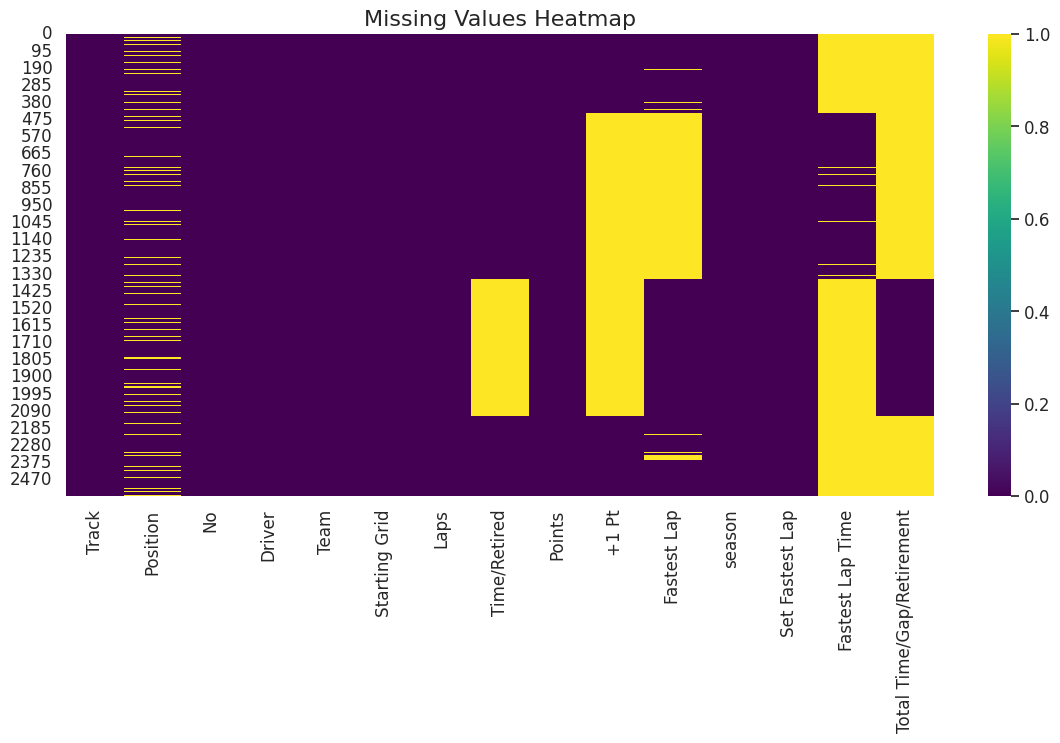

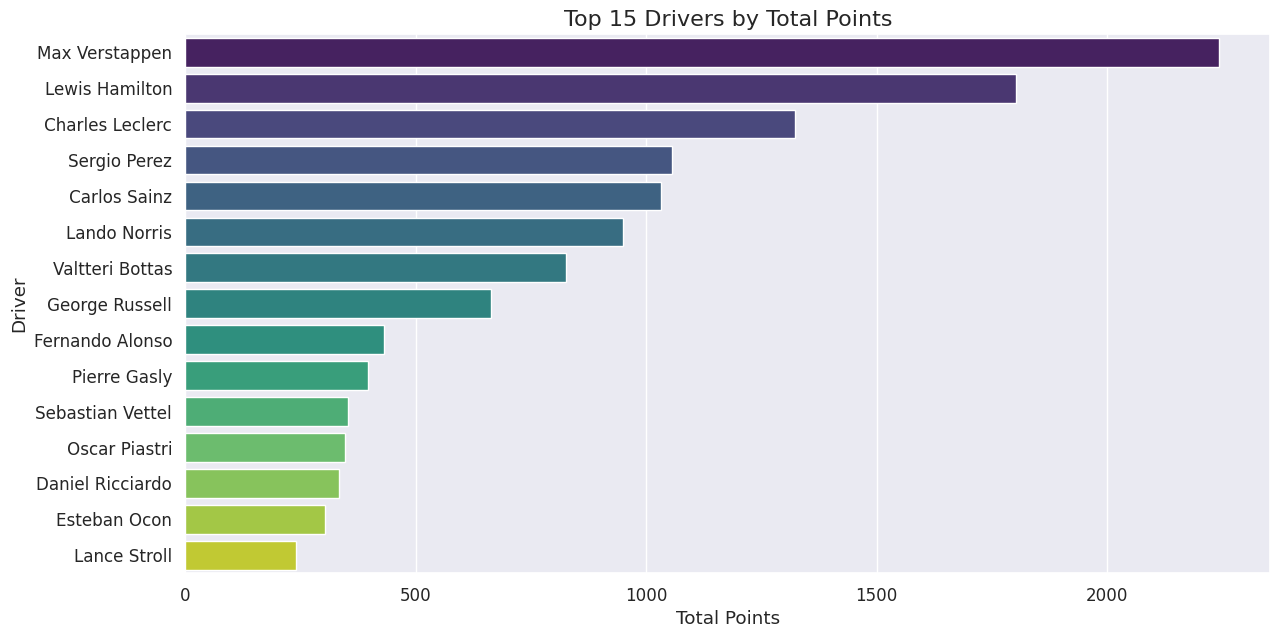

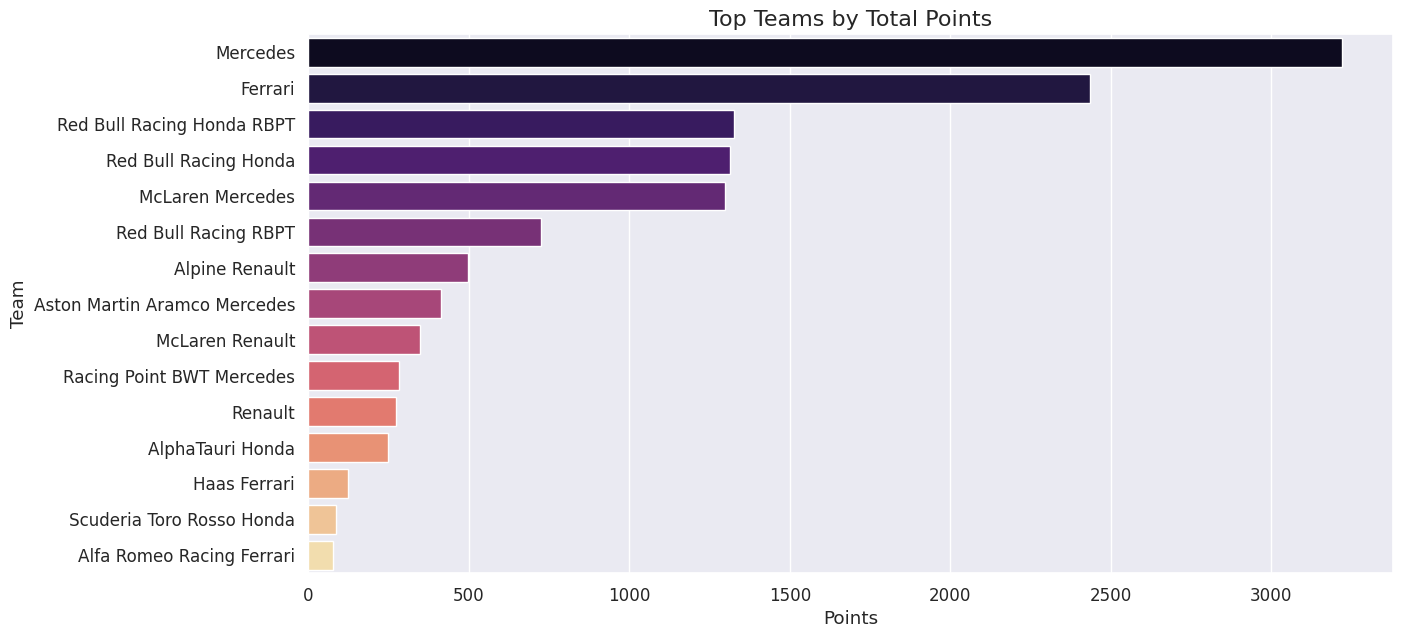

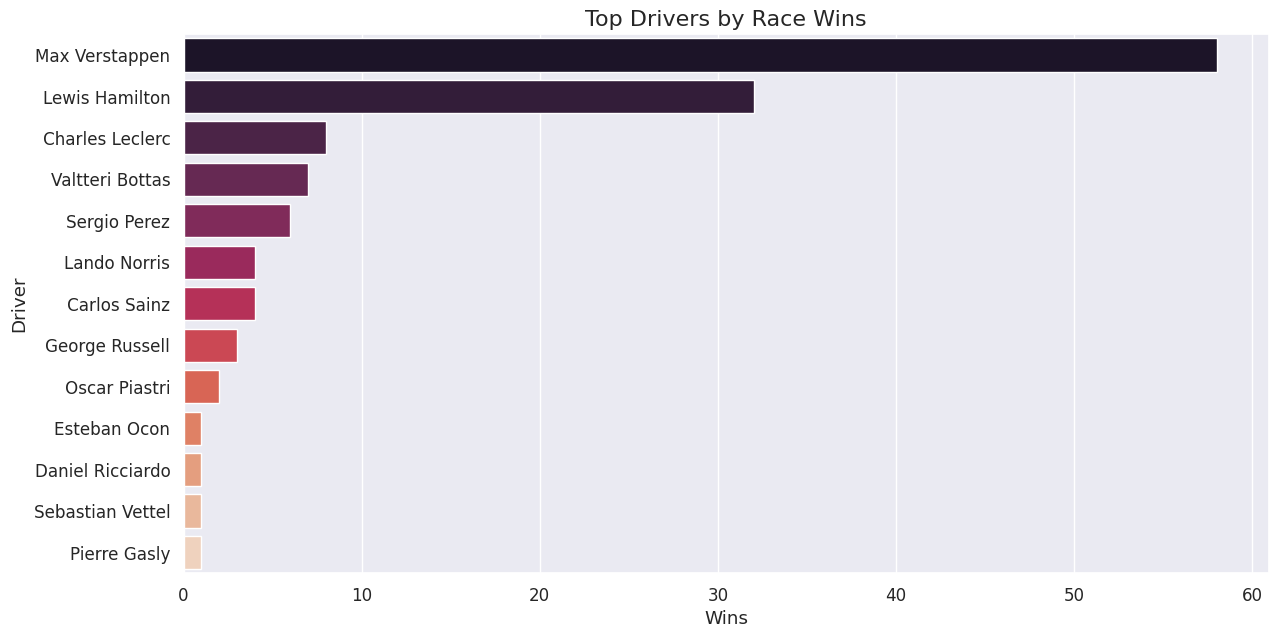

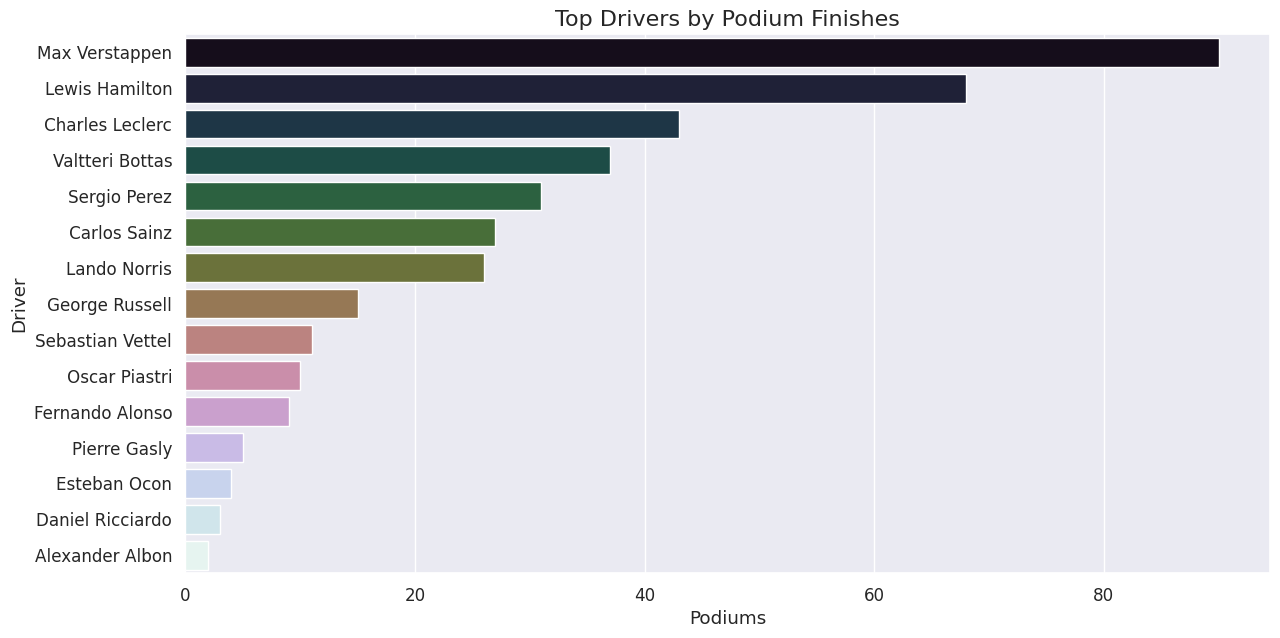

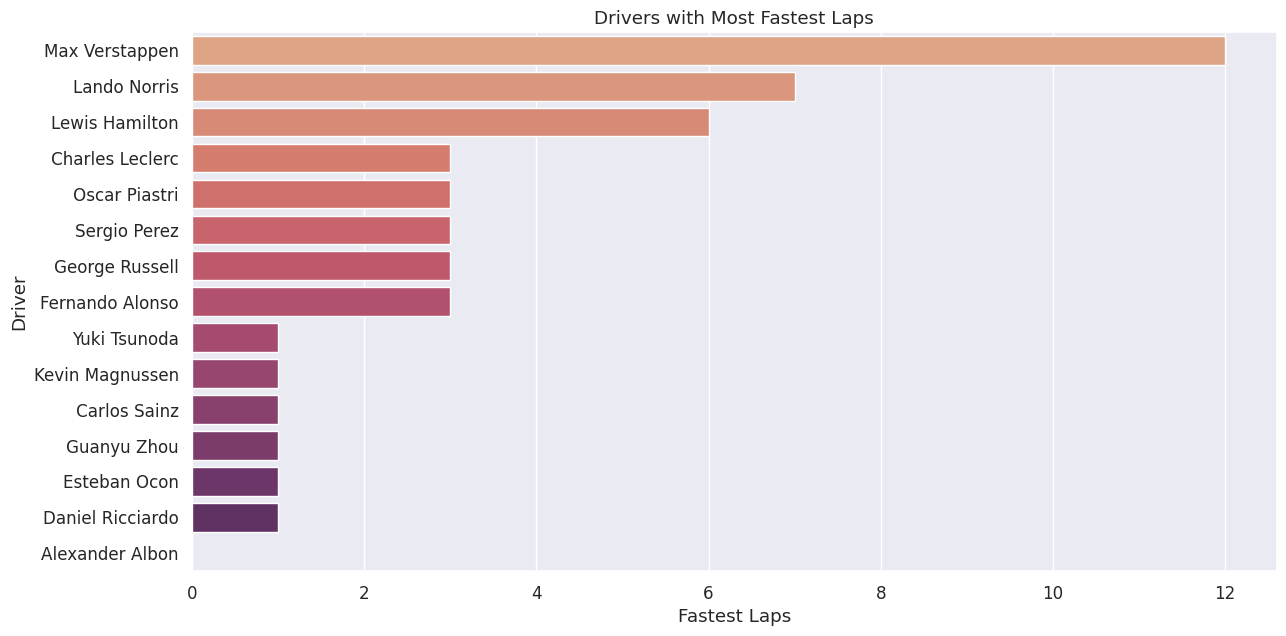

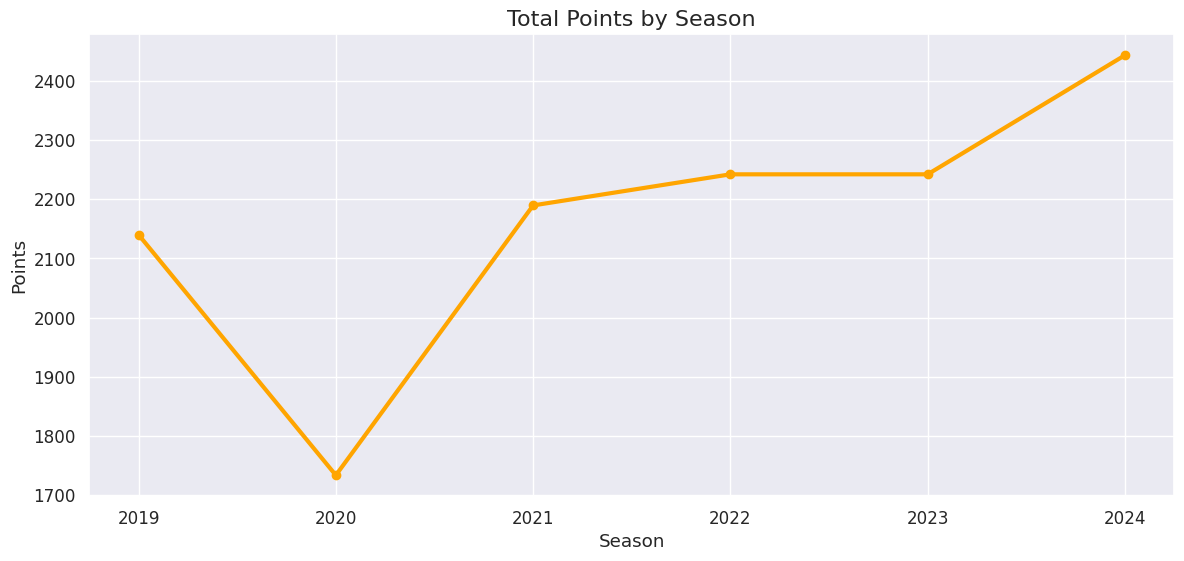

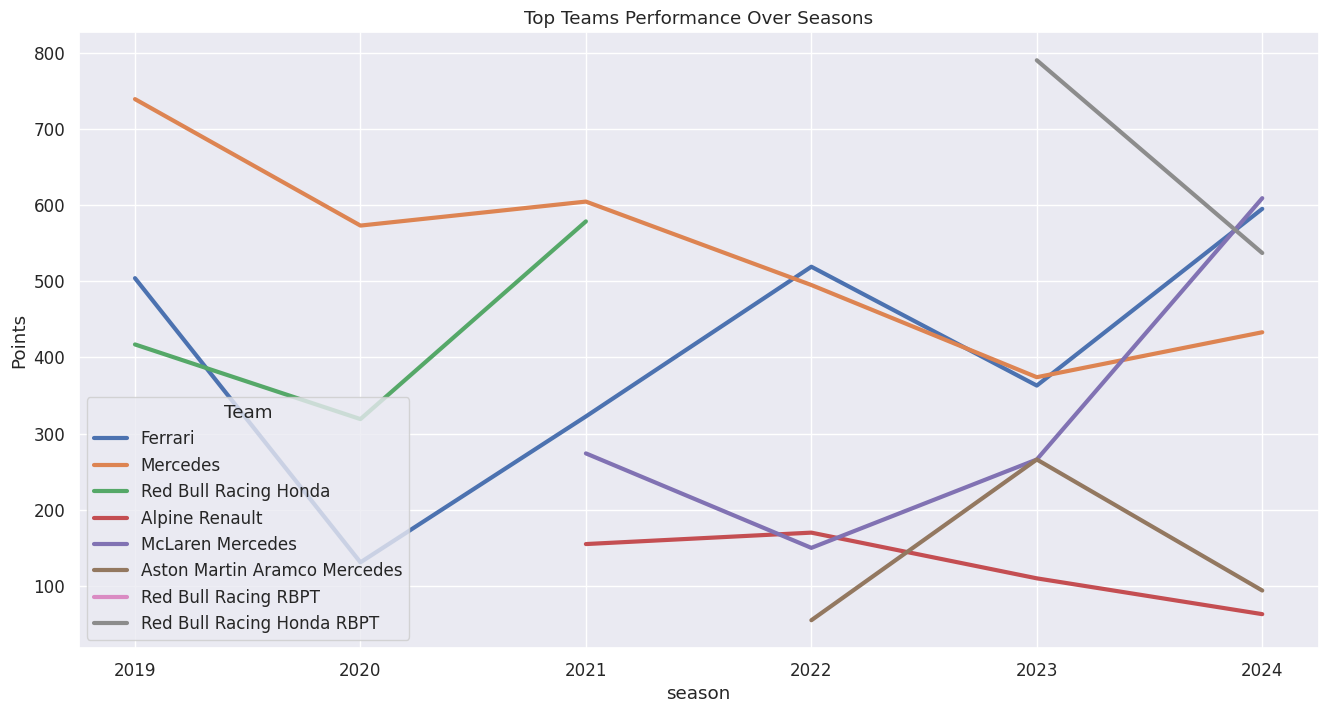

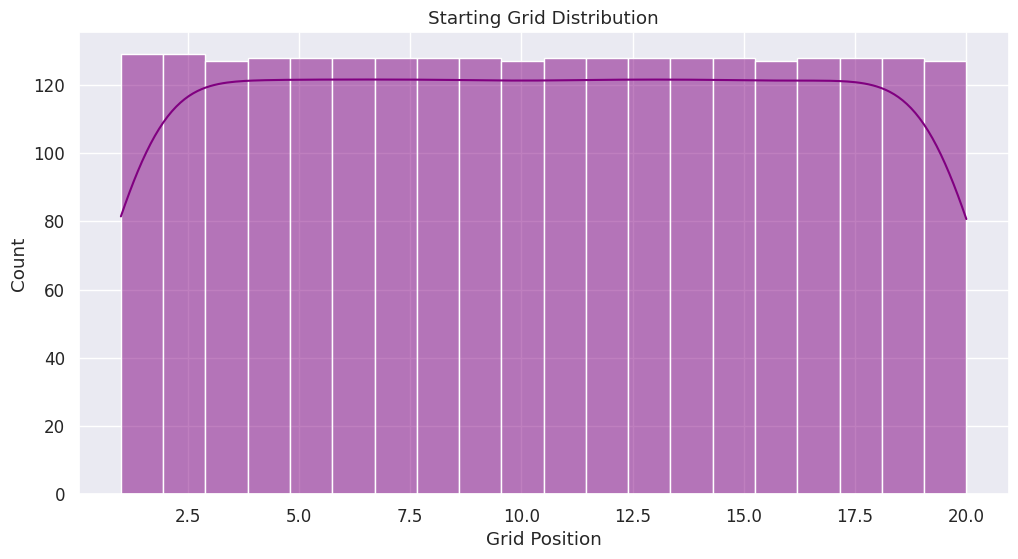

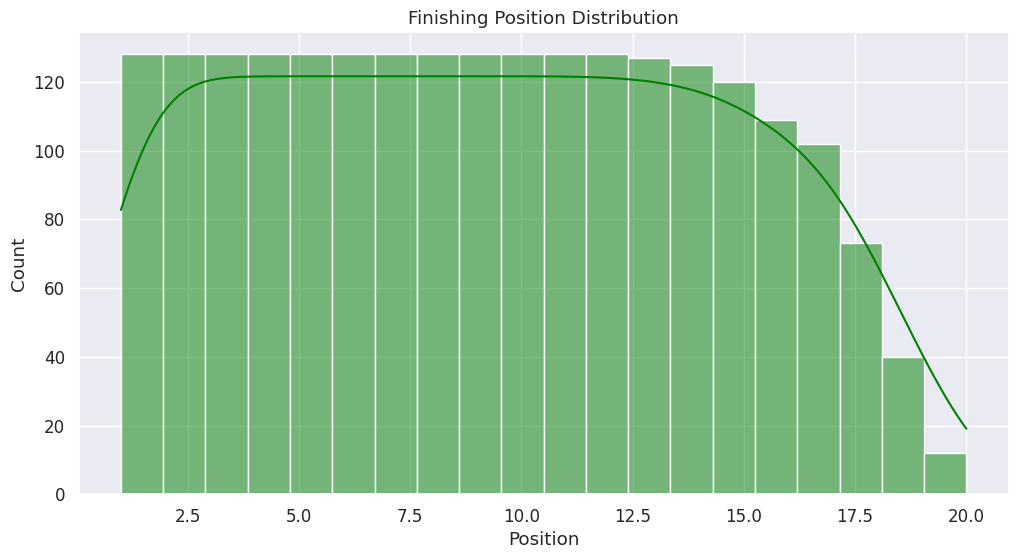

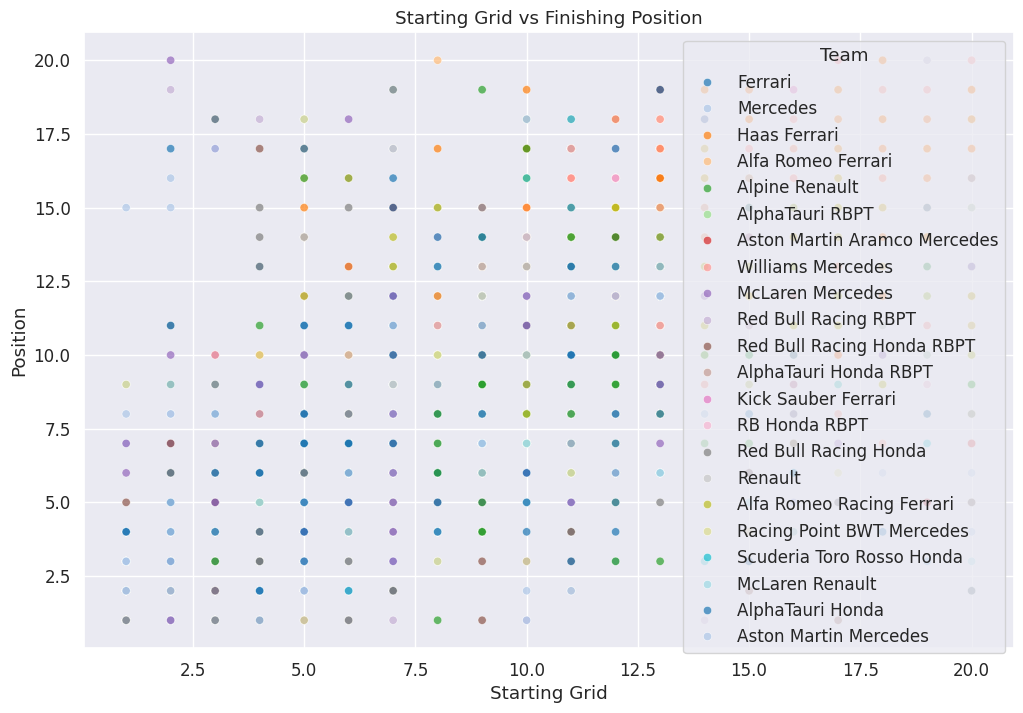

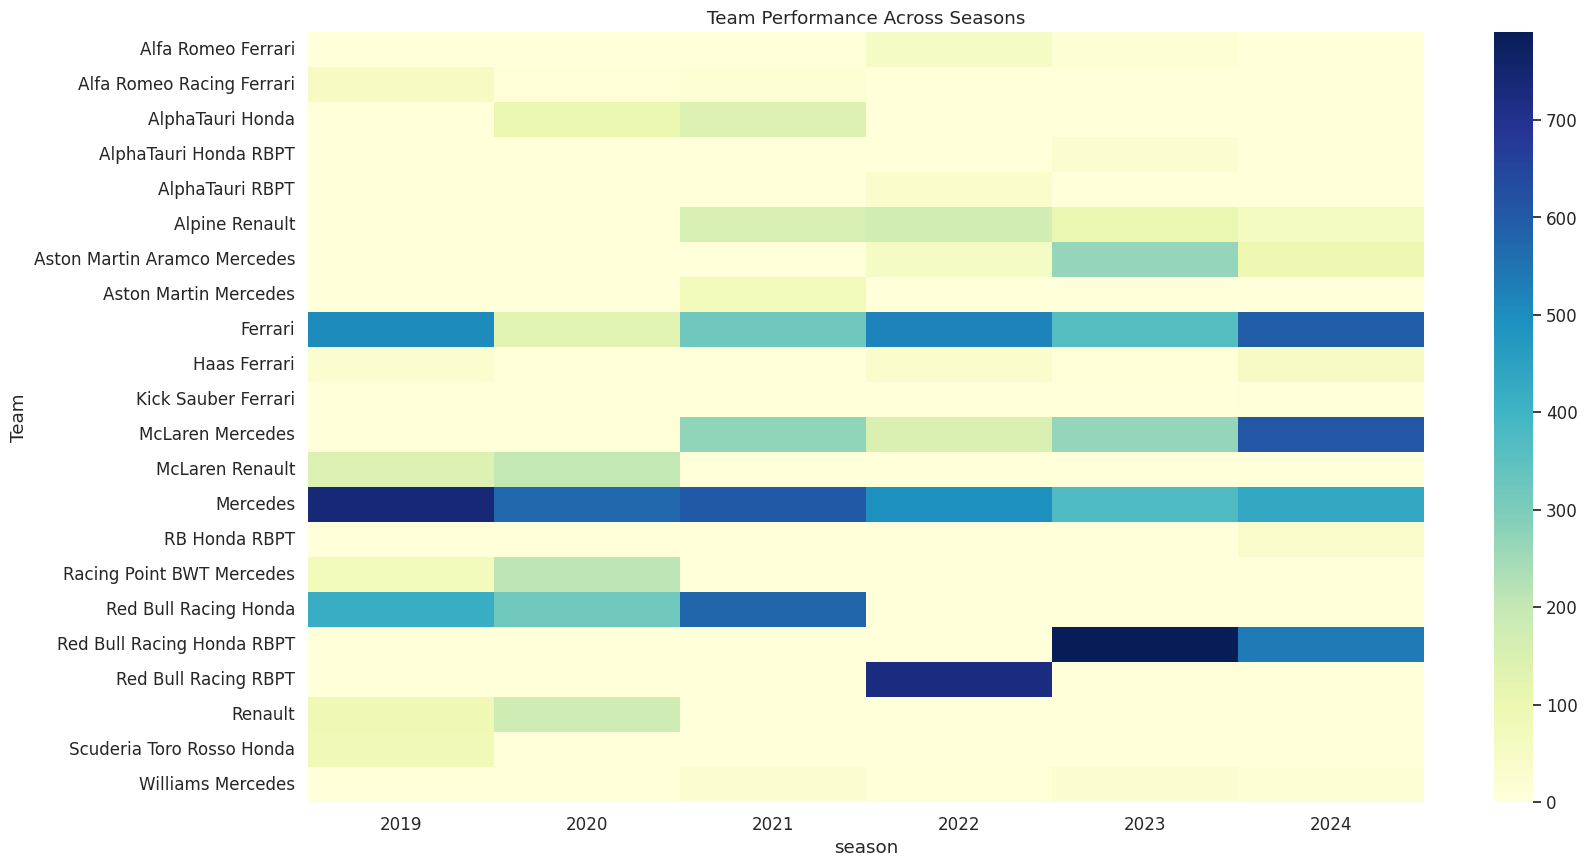

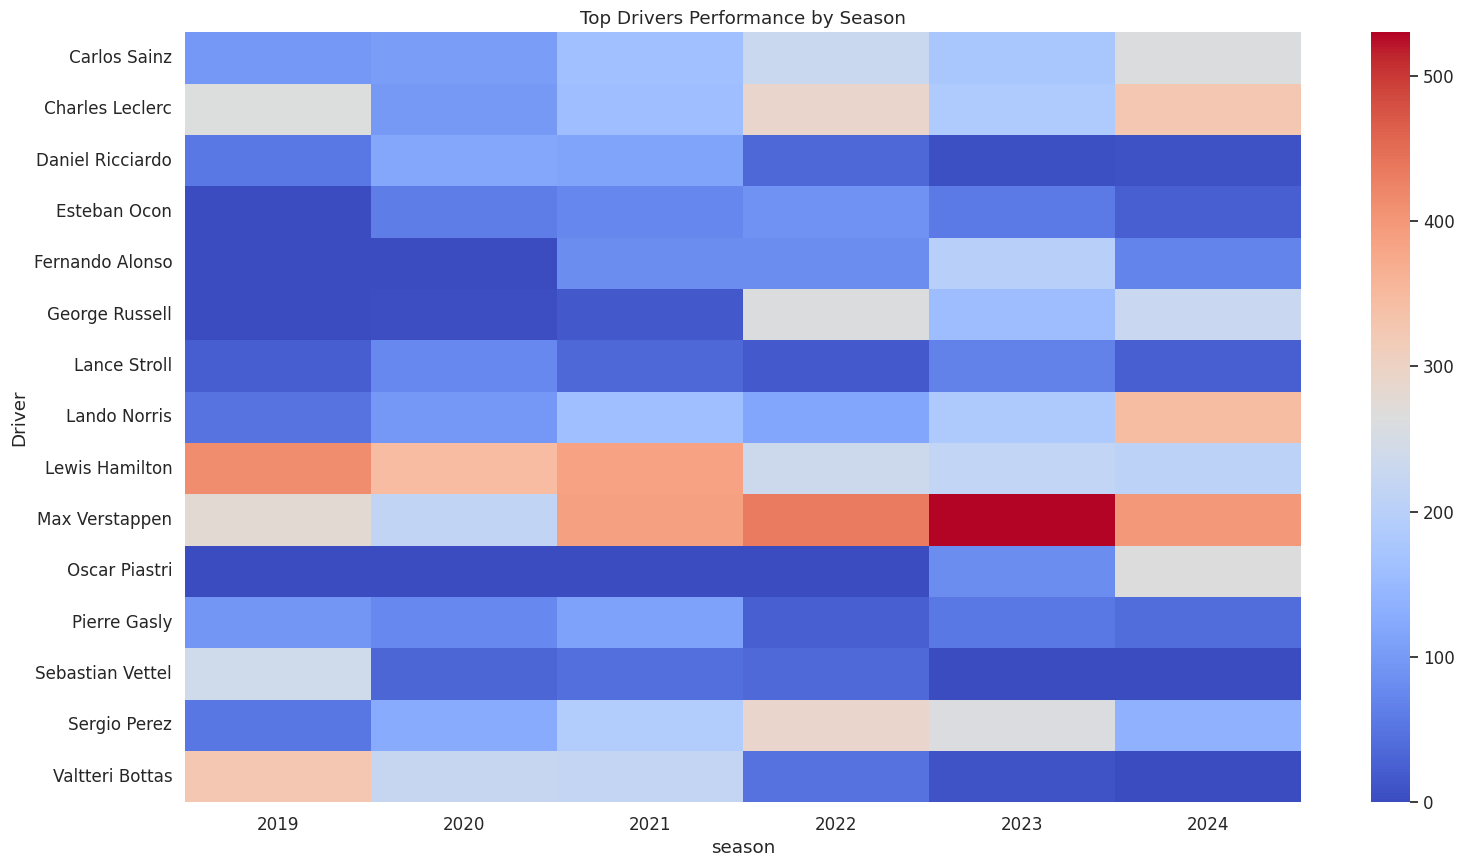

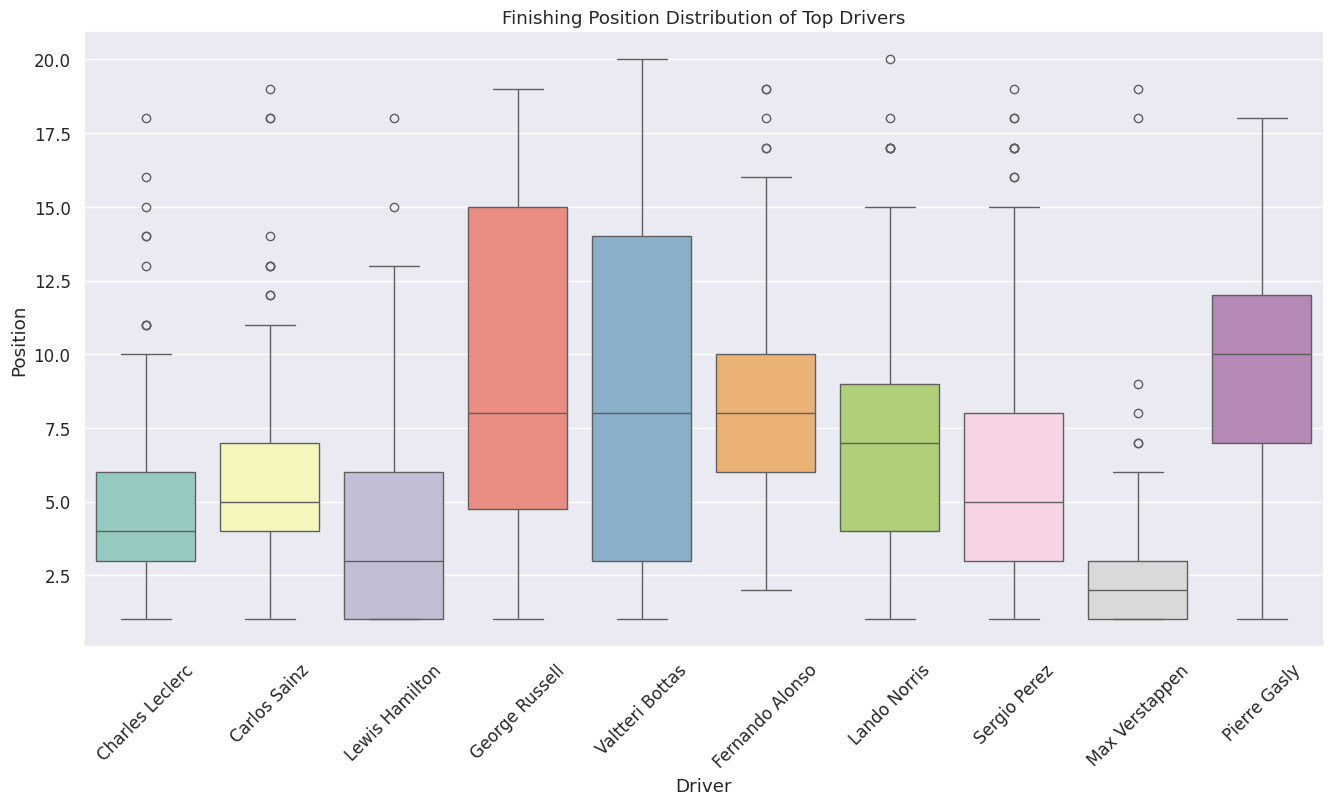

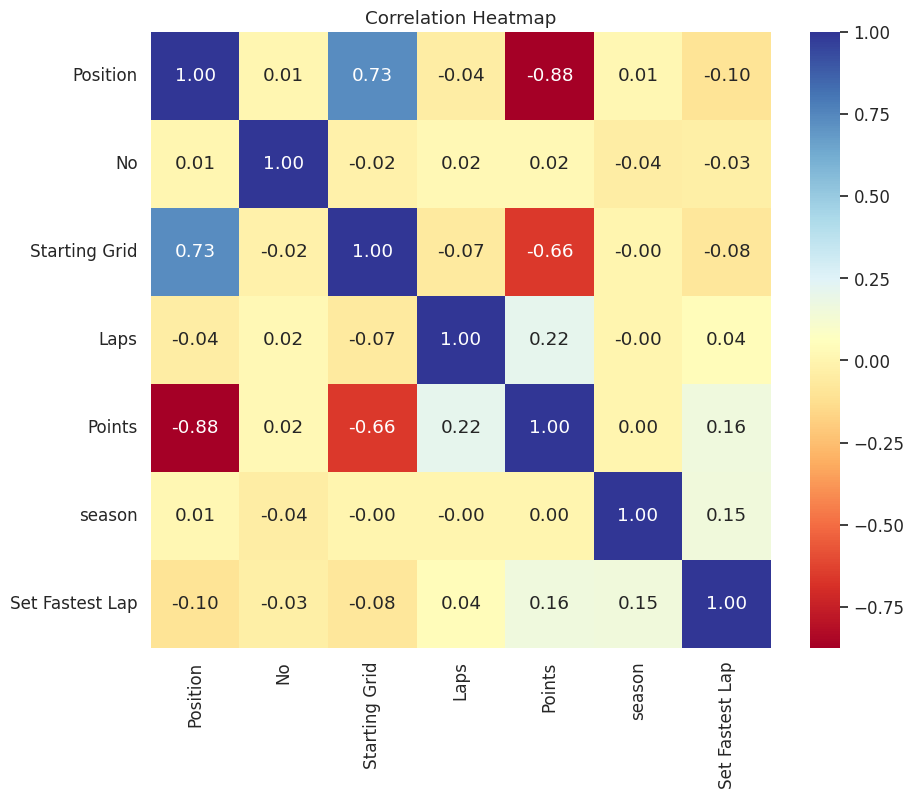

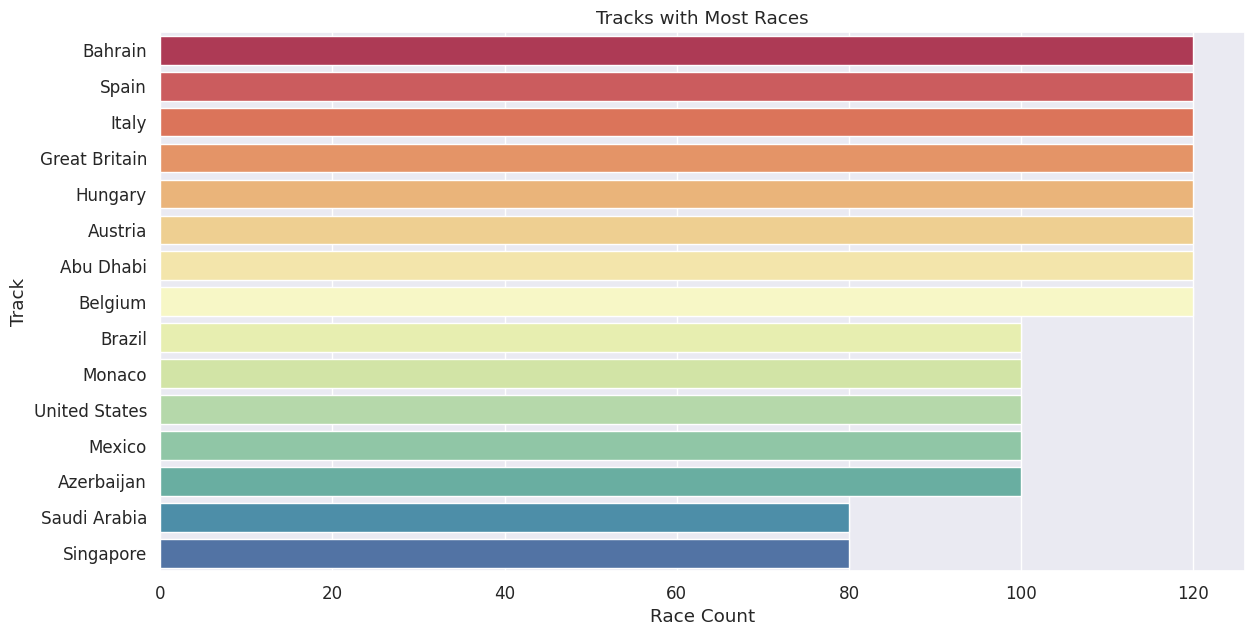

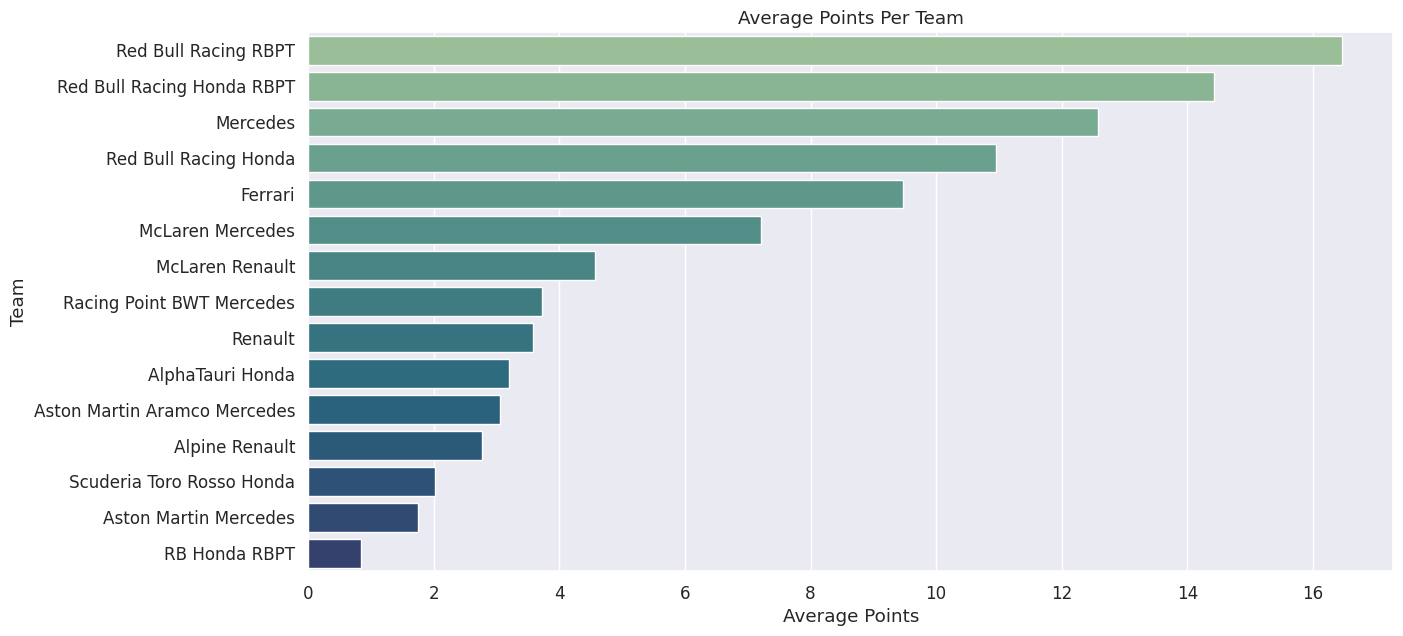

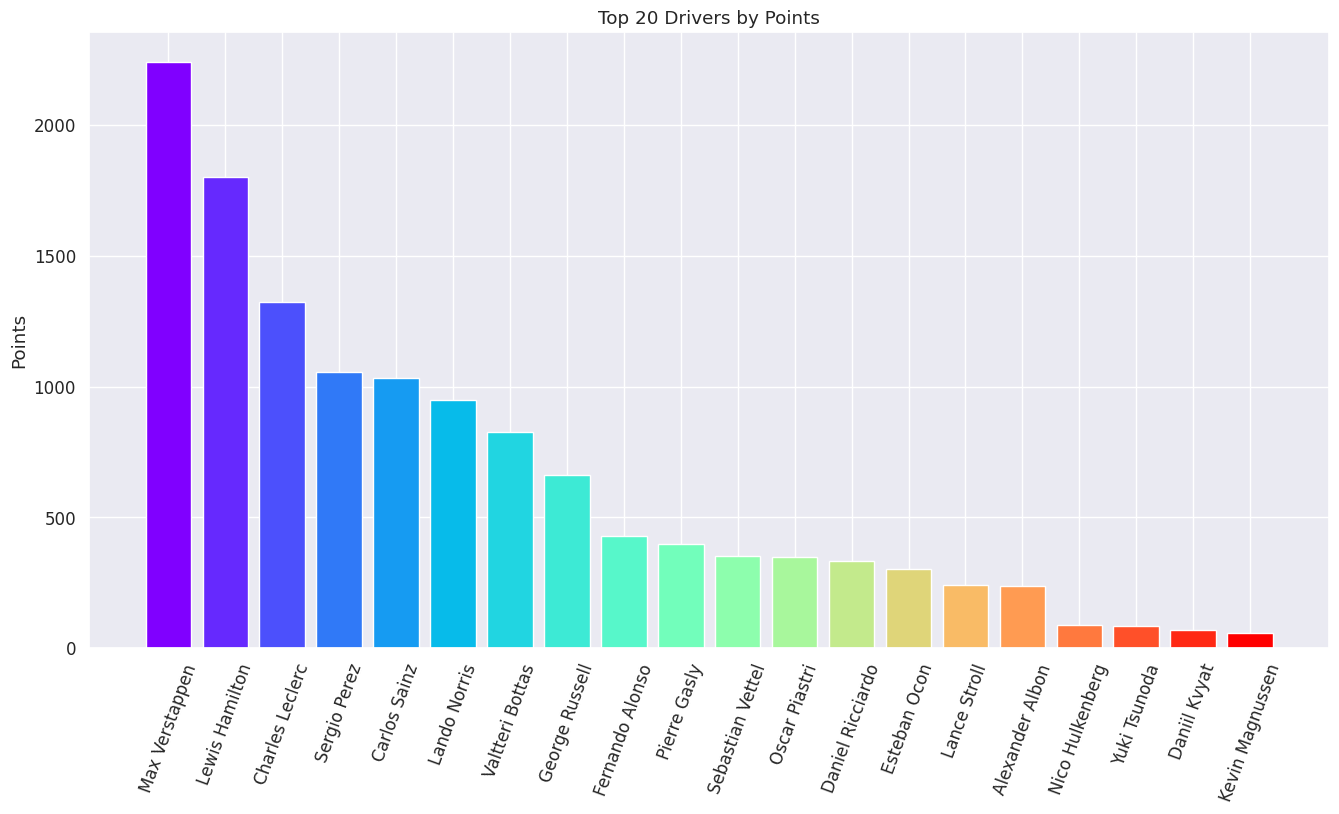


Top 10 Drivers by Points


Driver
Max Verstappen     2242.5
Lewis Hamilton     1802.5
Charles Leclerc    1324.0
Sergio Perez       1056.0
Carlos Sainz       1032.5
Lando Norris        950.0
Valtteri Bottas     825.0
George Russell      664.0
Fernando Alonso     430.0
Pierre Gasly        397.0
Name: Points, dtype: float64


Top 10 Teams by Points


Team
Mercedes                        3218.5
Ferrari                         2434.5
Red Bull Racing Honda RBPT      1327.0
Red Bull Racing Honda           1314.5
McLaren Mercedes                1299.0
Red Bull Racing RBPT             724.0
Alpine Renault                   498.0
Aston Martin Aramco Mercedes     415.0
McLaren Renault                  347.0
Racing Point BWT Mercedes        283.0
Name: Points, dtype: float64


EDA Completed Successfully!


In [15]:
plt.style.use('ggplot')
sns.set(font_scale=1.1)

# ============================================================
# 1. MISSING VALUES HEATMAP
# ============================================================

plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=16)
plt.show()

# ============================================================
# 2. TOP DRIVERS BY TOTAL POINTS
# ============================================================

driver_points = (
    df.groupby('Driver')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=driver_points.values,
    y=driver_points.index,
    palette='viridis'
)
plt.title('Top 15 Drivers by Total Points', fontsize=16)
plt.xlabel('Total Points')
plt.ylabel('Driver')
plt.show()

# ============================================================
# 3. TOP TEAMS BY TOTAL POINTS
# ============================================================

team_points = (
    df.groupby('Team')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=team_points.values,
    y=team_points.index,
    palette='magma'
)
plt.title('Top Teams by Total Points', fontsize=16)
plt.xlabel('Points')
plt.ylabel('Team')
plt.show()

# ============================================================
# 4. DRIVER WINS COUNT
# ============================================================

wins = (
    df[df['Position'] == 1]
    .groupby('Driver')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=wins.values,
    y=wins.index,
    palette='rocket'
)
plt.title('Top Drivers by Race Wins', fontsize=16)
plt.xlabel('Wins')
plt.ylabel('Driver')
plt.show()

# ============================================================
# 5. PODIUM FINISHES
# ============================================================

podiums = (
    df[df['Position'] <= 3]
    .groupby('Driver')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))
sns.barplot(
    x=podiums.values,
    y=podiums.index,
    palette='cubehelix'
)
plt.title('Top Drivers by Podium Finishes', fontsize=16)
plt.xlabel('Podiums')
plt.ylabel('Driver')
plt.show()

# ============================================================
# 6. FASTEST LAPS BY DRIVER
# ============================================================

if 'Set Fastest Lap' in df.columns:

    fastest_laps = (
        df.groupby('Driver')['Set Fastest Lap']
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

    plt.figure(figsize=(14,7))
    sns.barplot(
        x=fastest_laps.values,
        y=fastest_laps.index,
        palette='flare'
    )
    plt.title('Drivers with Most Fastest Laps')
    plt.xlabel('Fastest Laps')
    plt.ylabel('Driver')
    plt.show()

# ============================================================
# 7. POINTS BY SEASON
# ============================================================

season_points = (
    df.groupby('season')['Points']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))
plt.plot(
    season_points['season'],
    season_points['Points'],
    marker='o',
    linewidth=3,
    color='orange'
)
plt.title('Total Points by Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Points')
plt.grid(True)
plt.show()

# ============================================================
# 8. TEAM PERFORMANCE BY SEASON
# ============================================================

team_season = (
    df.groupby(['season','Team'])['Points']
    .sum()
    .reset_index()
)

top_teams = (
    df.groupby('Team')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

filtered = team_season[
    team_season['Team'].isin(top_teams)
]

plt.figure(figsize=(16,8))

sns.lineplot(
    data=filtered,
    x='season',
    y='Points',
    hue='Team',
    linewidth=3
)

plt.title('Top Teams Performance Over Seasons')
plt.show()

# ============================================================
# 9. STARTING GRID DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))
sns.histplot(
    df['Starting Grid'],
    bins=20,
    kde=True,
    color='purple'
)
plt.title('Starting Grid Distribution')
plt.xlabel('Grid Position')
plt.show()

# ============================================================
# 10. FINISHING POSITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))
sns.histplot(
    df['Position'],
    bins=20,
    kde=True,
    color='green'
)
plt.title('Finishing Position Distribution')
plt.xlabel('Position')
plt.show()

# ============================================================
# 11. STARTING GRID VS FINISH POSITION
# ============================================================

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df,
    x='Starting Grid',
    y='Position',
    hue='Team',
    palette='tab20',
    alpha=0.7
)

plt.title('Starting Grid vs Finishing Position')
plt.show()

# ============================================================
# 12. TEAM VS SEASON HEATMAP
# ============================================================

heatmap_data = pd.pivot_table(
    df,
    values='Points',
    index='Team',
    columns='season',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(18,10))
sns.heatmap(
    heatmap_data,
    cmap='YlGnBu',
    annot=False
)
plt.title('Team Performance Across Seasons')
plt.show()

# ============================================================
# 13. DRIVER VS SEASON HEATMAP
# ============================================================

top_drivers = (
    df.groupby('Driver')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

driver_heat = pd.pivot_table(
    df[df['Driver'].isin(top_drivers)],
    values='Points',
    index='Driver',
    columns='season',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(18,10))
sns.heatmap(
    driver_heat,
    cmap='coolwarm',
    annot=False
)

plt.title('Top Drivers Performance by Season')
plt.show()

# ============================================================
# 14. BOXPLOT OF FINISHING POSITION BY TOP DRIVERS
# ============================================================

top_driver_names = (
    df.groupby('Driver')['Points']
    .sum()
    .nlargest(10)
    .index
)

plt.figure(figsize=(16,8))

sns.boxplot(
    data=df[df['Driver'].isin(top_driver_names)],
    x='Driver',
    y='Position',
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title('Finishing Position Distribution of Top Drivers')
plt.show()

# ============================================================
# 15. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='RdYlBu',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# ============================================================
# 16. TRACKS WITH MOST RACES
# ============================================================

track_count = (
    df['Track']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=track_count.values,
    y=track_count.index,
    palette='Spectral'
)

plt.title('Tracks with Most Races')
plt.xlabel('Race Count')
plt.ylabel('Track')
plt.show()

# ============================================================
# 17. AVERAGE POINTS PER TEAM
# ============================================================

avg_team_points = (
    df.groupby('Team')['Points']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(14,7))

sns.barplot(
    x=avg_team_points.values,
    y=avg_team_points.index,
    palette='crest'
)

plt.title('Average Points Per Team')
plt.xlabel('Average Points')
plt.ylabel('Team')
plt.show()

# ============================================================
# 18. TOP DRIVERS TREEMAP STYLE (BAR VERSION)
# ============================================================

top20 = (
    df.groupby('Driver')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

colors = plt.cm.rainbow(
    np.linspace(0,1,len(top20))
)

plt.figure(figsize=(16,8))

plt.bar(
    top20.index,
    top20.values,
    color=colors
)

plt.xticks(rotation=70)
plt.title('Top 20 Drivers by Points')
plt.ylabel('Points')
plt.show()

# ============================================================
# SUMMARY TABLES
# ============================================================

print("\nTop 10 Drivers by Points")
display(
    df.groupby('Driver')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Teams by Points")
display(
    df.groupby('Team')['Points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nEDA Completed Successfully!")

## Feature Engineering

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

In [17]:
print(df.shape)

(2559, 15)


In [18]:
df['Target'] = np.where(df['Position'] <= 3, 1, 0)

print(df['Target'].value_counts())

Target
0    2175
1     384
Name: count, dtype: int64


In [19]:
feature_cols = [
    'Track',
    'No',
    'Driver',
    'Team',
    'Starting Grid',
    'Laps',
    'season'
]

X = df[feature_cols]
y = df['Target']


Train Shape: (2047, 7)
Test Shape : (512, 7)
Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       435
           1       0.71      0.71      0.71        77

    accuracy                           0.91       512
   macro avg       0.83      0.83      0.83       512
weighted avg       0.91      0.91      0.91       512

Accuracy : 0.9121
Precision: 0.7051
Recall   : 0.7143
F1 Score : 0.7097
ROC AUC  : 0.9444
Random Forest
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       435
           1       0.68      0.62      0.65        77

    accuracy                           0.90       512
   macro avg       0.81      0.79      0.79       512
weighted avg       0.90      0.90      0.90       512

Accuracy : 0.8984
Precision: 0.6761
Recall   : 0.6234
F1 Score : 0.6486
ROC AUC  : 0.9295
Gradient Boosting
              precision    recall  f1-score   support

           0  

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.912109,0.705128,0.714286,0.709677,0.944380
2,Gradient Boosting,0.910156,0.701299,0.701299,0.701299,0.937035
1,Random Forest,0.898438,0.676056,0.623377,0.648649,0.929482
3,Extra Trees,0.892578,0.644737,0.636364,0.640523,0.917734


<Figure size 800x600 with 0 Axes>

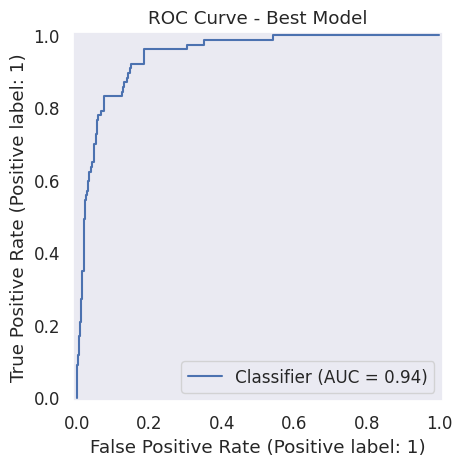

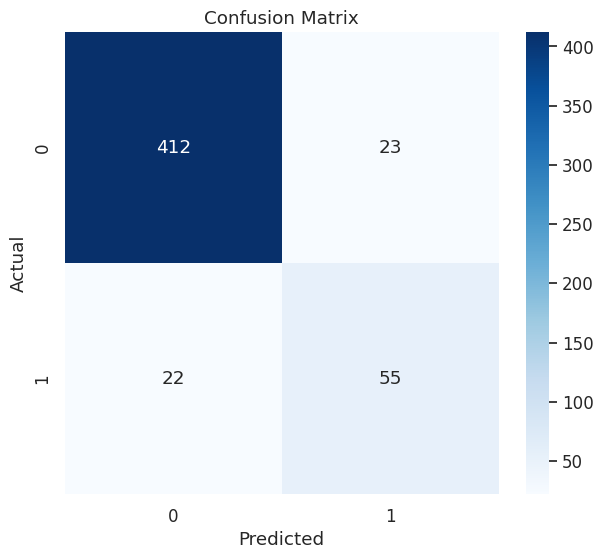

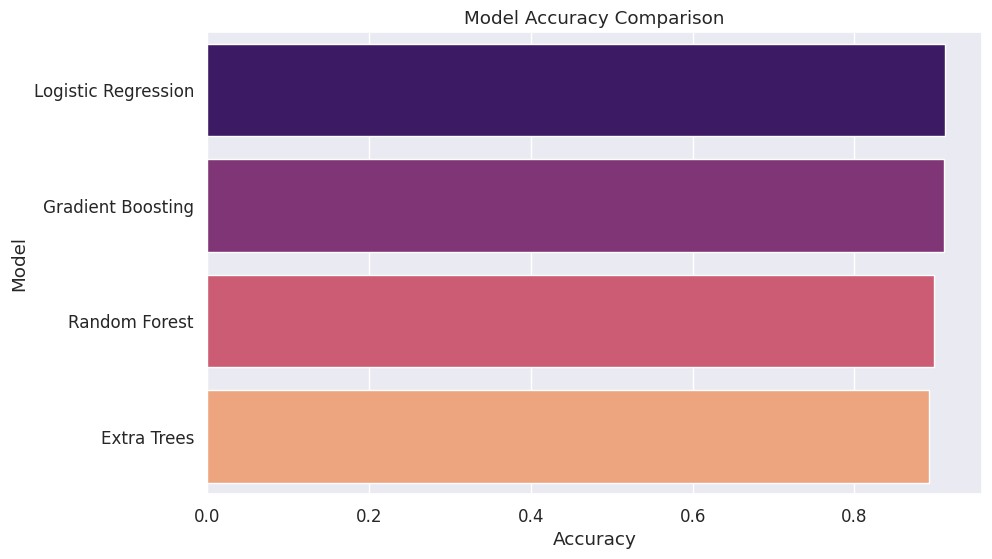

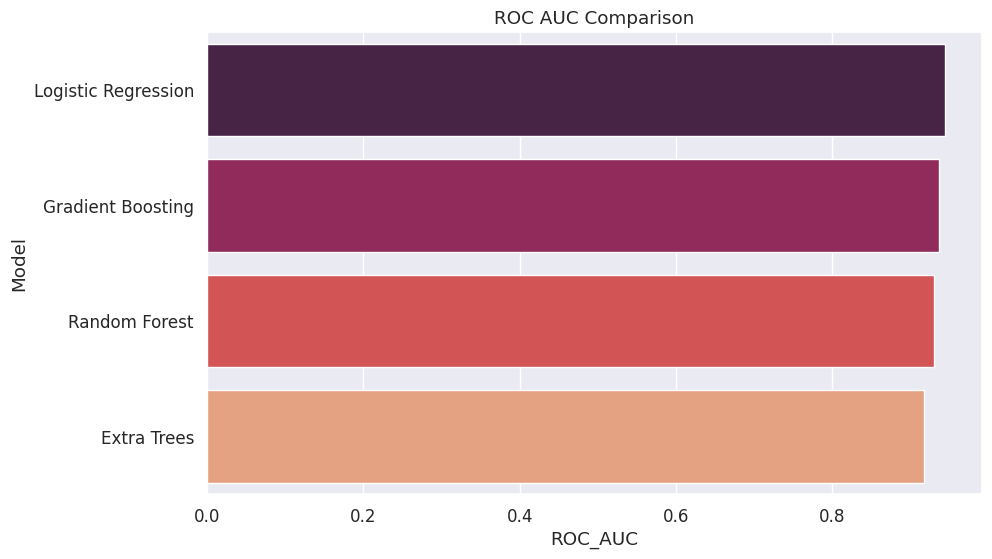


Best ROC AUC: 0.9443797581728616


In [20]:
categorical_features = [
    'Track',
    'Driver',
    'Team'
]

numerical_features = [
    'No',
    'Starting Grid',
    'Laps',
    'season'
]

# ============================================================
# PREPROCESSOR
# ============================================================

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ]
)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ============================================================
# MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=5000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
}

# ============================================================
# TRAIN MODELS
# ============================================================

results = []

best_model = None
best_auc = 0

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    print("="*60)
    print(name)
    print("="*60)

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    prob = pipe.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)

    results.append([
        name,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    print(classification_report(y_test, pred))

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        best_model = pipe

# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC_AUC'
    ]
)

results_df = results_df.sort_values(
    'ROC_AUC',
    ascending=False
)

print("\nModel Comparison")
display(results_df)

# ============================================================
# BEST MODEL ROC CURVE
# ============================================================

best_probs = best_model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    best_probs
)

plt.title("ROC Curve - Best Model")
plt.grid()
plt.show()

# ============================================================
# CONFUSION MATRIX
# ============================================================

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

if hasattr(best_model.named_steps['model'], 'feature_importances_'):

    feature_names = (
        best_model.named_steps['preprocessor']
        .get_feature_names_out()
    )

    importance = (
        best_model.named_steps['model']
        .feature_importances_
    )

    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })

    feat_imp = feat_imp.sort_values(
        'Importance',
        ascending=False
    )

    plt.figure(figsize=(12,8))

    sns.barplot(
        data=feat_imp.head(20),
        x='Importance',
        y='Feature',
        palette='viridis'
    )

    plt.title("Top 20 Important Features")
    plt.show()

# ============================================================
# ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model',
    palette='magma'
)

plt.title("Model Accuracy Comparison")
plt.show()

# ============================================================
# ROC AUC COMPARISON
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='ROC_AUC',
    y='Model',
    palette='rocket'
)

plt.title("ROC AUC Comparison")
plt.show()

print("\nBest ROC AUC:", best_auc)

## Thank you...pls upvote!!!!!!!!!!!!!!!!!!